In [ ]:
import pandas as pd

# Load dataset
file_path = "C:/Users/shenbagam/Downloads/swiggy/swiggy.csv"
df = pd.read_csv(file_path)

print("Shape of dataset:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)

print("\nFirst 5 rows:\n", df.head())

null_counts = df.isnull().sum()
null_percent = (df.isnull().sum() / len(df)) * 100
null_summary = pd.DataFrame({
    'Null Count': null_counts,
    'Null Percentage': null_percent.round(2)
}).sort_values(by='Null Count', ascending=False)

print("\nMissing values per column (sorted):\n", null_summary)
print("\nTotal missing values in dataset:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\n--- Findings on Null Values ---")
for col in null_summary.index:
    if null_summary.loc[col, 'Null Count'] > 0:
        print(f"Column '{col}' has {null_summary.loc[col, 'Null Count']} "
              f"missing values ({null_summary.loc[col, 'Null Percentage']}%).")

print("\nSummary statistics:\n", df.describe(include='all'))

for col in df.columns:
    print(f"\nColumn: {col}")
    print("Unique values:", df[col].nunique())

categorical_cols = df.select_dtypes(include=['object', 'string']).columns
for col in categorical_cols:
    print(f"\nValue counts for {col}:\n", df[col].value_counts().head(10))

print("\nCorrelation matrix:\n", df.corr(numeric_only=True))


Shape of dataset: (148541, 11)

Column names: ['id', 'name', 'city', 'rating', 'rating_count', 'cost', 'cuisine', 'lic_no', 'link', 'address', 'menu']

Data types:
 id              int64
name              str
city              str
rating            str
rating_count      str
cost              str
cuisine           str
lic_no            str
link              str
address           str
menu              str
dtype: object

First 5 rows:
        id               name    city rating     rating_count   cost  \
0  567335     AB FOODS POINT  Abohar     --  Too Few Ratings  ₹ 200   
1  531342  Janta Sweet House  Abohar    4.4      50+ ratings  ₹ 200   
2  158203  theka coffee desi  Abohar    3.8     100+ ratings  ₹ 100   
3  187912          Singh Hut  Abohar    3.7      20+ ratings  ₹ 250   
4  543530      GRILL MASTERS  Abohar     --  Too Few Ratings  ₹ 250   

                      cuisine          lic_no  \
0            Beverages,Pizzas  22122652000138   
1               Sweets,Bakery  1211720

In [ ]:
import pandas as pd

file_path = "C:/Users/shenbagam/Downloads/swiggy/swiggy.csv"
df = pd.read_csv(file_path)
df = df[['id','name','city','cuisine','rating','cost']].copy()
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['cost'] = (
    df['cost'].astype(str)
    .str.replace('₹','', regex=False)
    .str.replace(',','', regex=False)
    .str.strip()
)
df['cost'] = pd.to_numeric(df['cost'], errors='coerce')
df['city'] = df['city'].astype(str).str.strip().str.lower()
df['cuisine'] = df['cuisine'].astype(str).str.strip().str.lower()
df = df.dropna(subset=['rating','cost'])

df = df.drop_duplicates()
cleaned_path = "C:/Users/shenbagam/Downloads/swiggy/cleaneddata.csv"
df.to_csv(cleaned_path, index=False)
print("✅ Cleaned data saved at:", cleaned_path)

print("\nShape after cleaning:", df.shape)
print("Remaining missing values:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())


✅ Cleaned data saved at: C:/Users/shenbagam/Downloads/swiggy/cleaneddata.csv

Shape after cleaning: (61425, 6)
Remaining missing values:
 id         0
name       0
city       0
cuisine    4
rating     0
cost       0
dtype: int64
Duplicate rows: 0


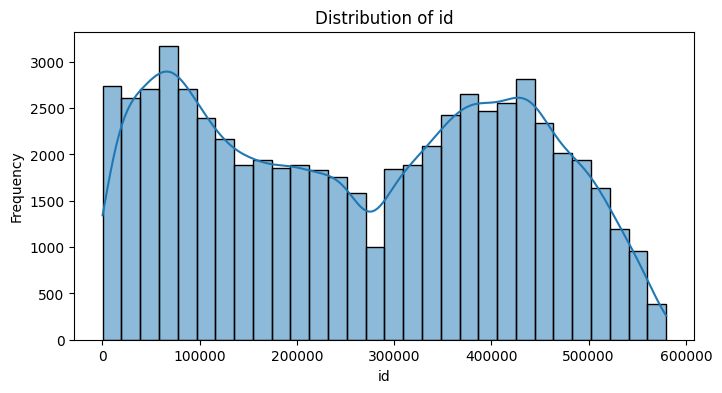

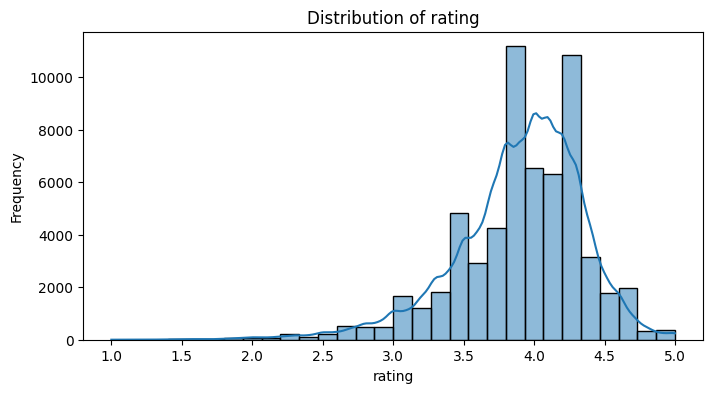

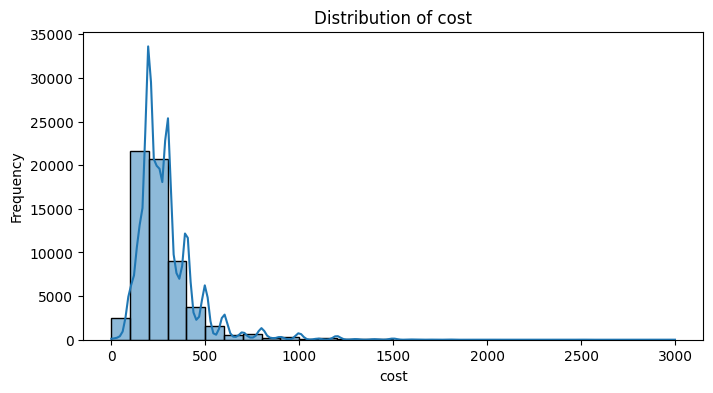

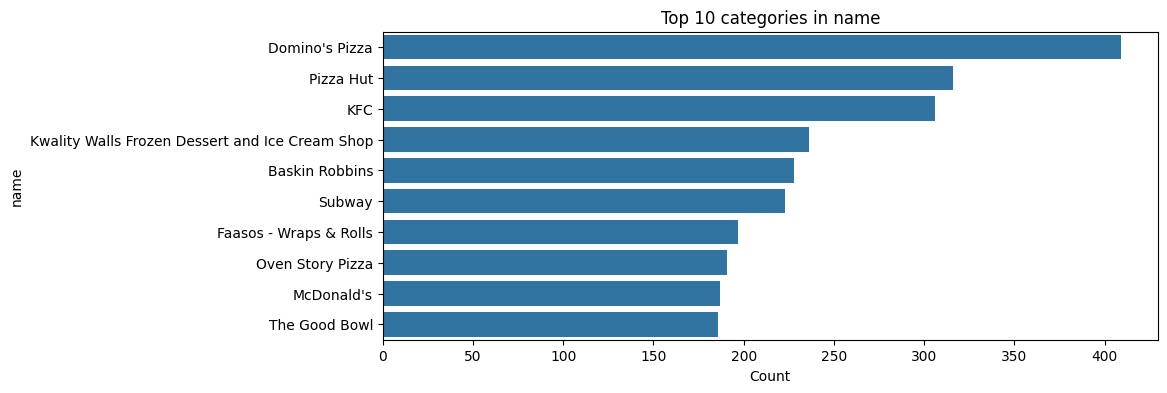

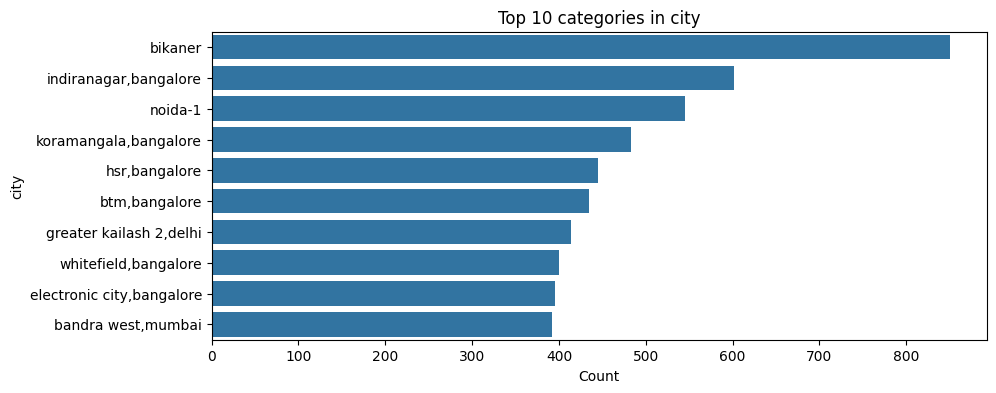

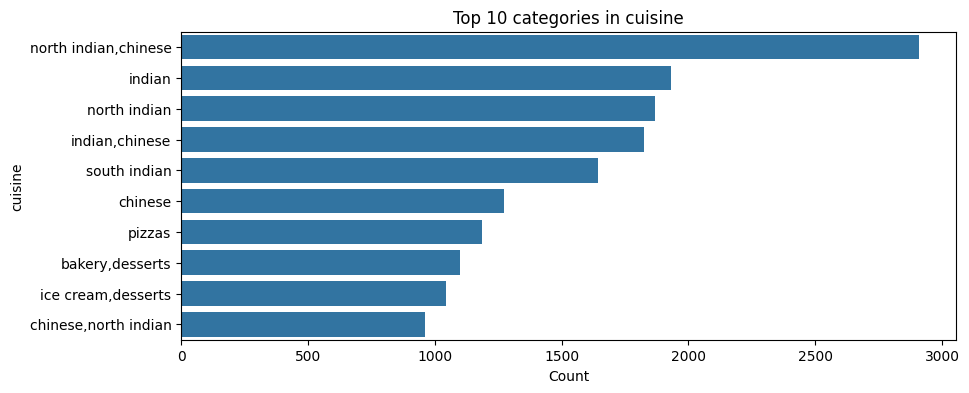

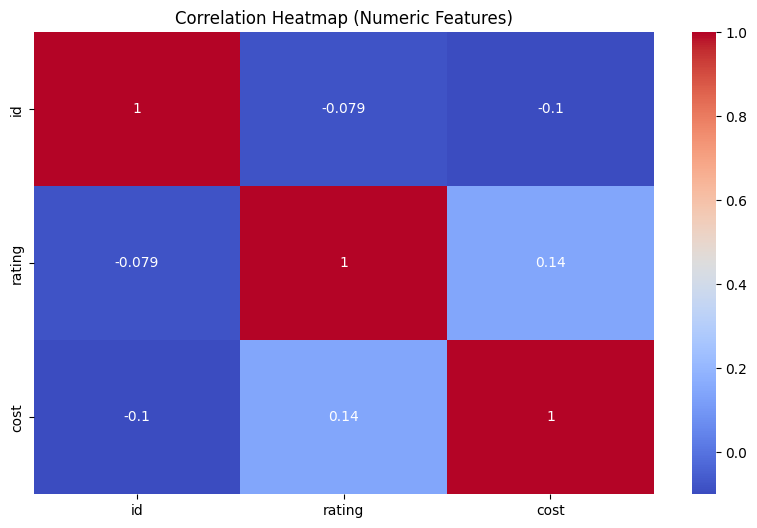

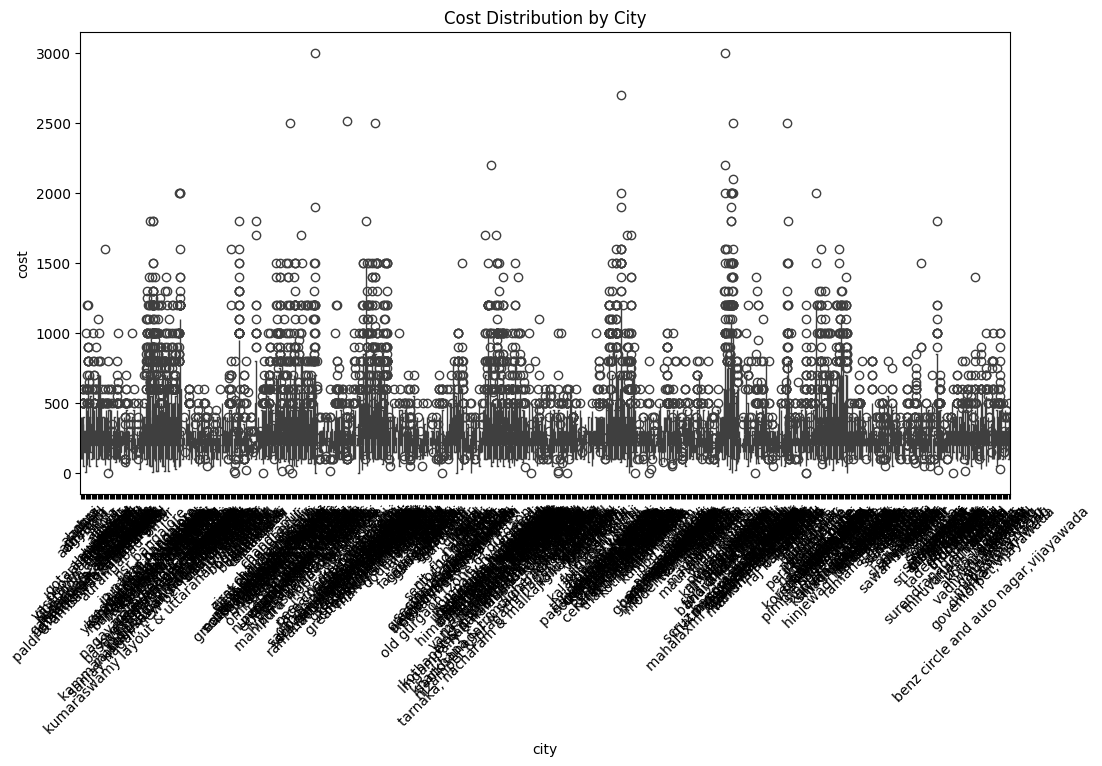

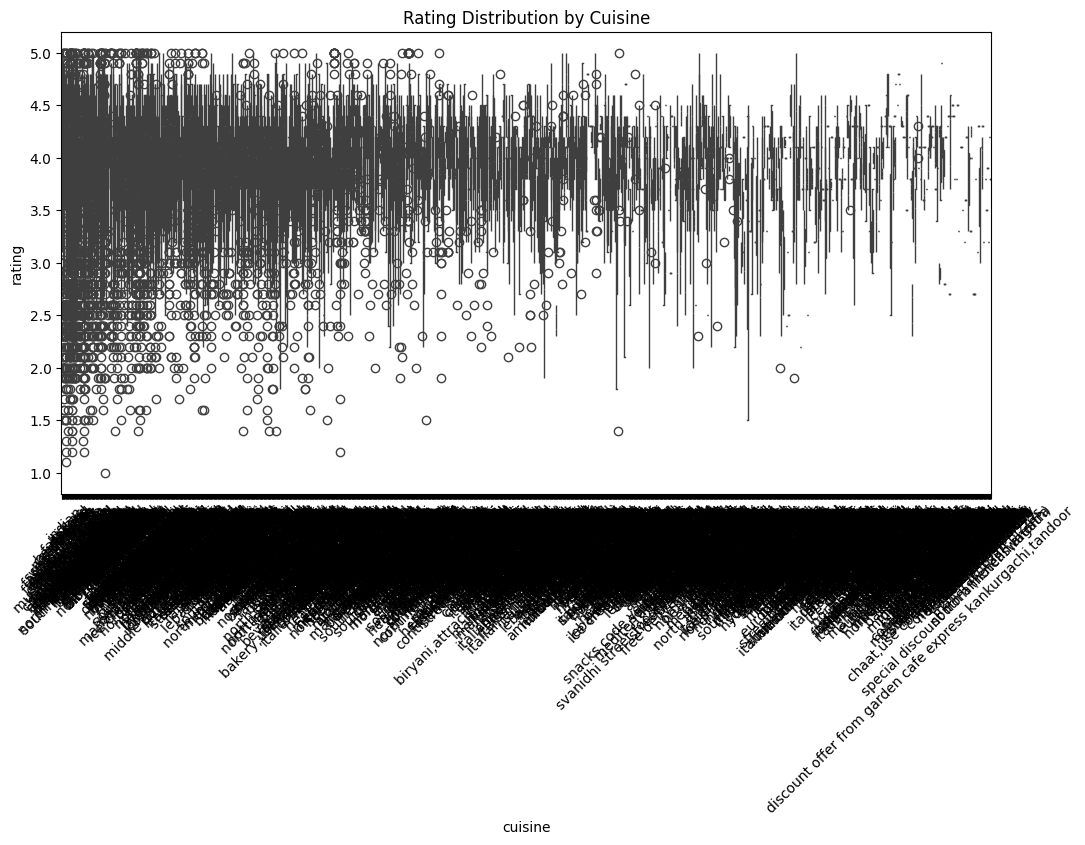

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = "C:/Users/shenbagam/Downloads/swiggy/cleaneddata.csv"
df = pd.read_csv(file_path)

numeric_cols = df.select_dtypes(include=['int64','float64']).columns
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

categorical_cols = df.select_dtypes(include=['object','string']).columns
for col in categorical_cols:
    plt.figure(figsize=(10,4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index[:10])
    plt.title(f"Top 10 categories in {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

if 'city' in df.columns and 'cost' in df.columns:
    plt.figure(figsize=(12,6))
    sns.boxplot(x='city', y='cost', data=df)
    plt.title("Cost Distribution by City")
    plt.xticks(rotation=45)
    plt.show()

if 'cuisine' in df.columns and 'rating' in df.columns:
    plt.figure(figsize=(12,6))
    sns.boxplot(x='cuisine', y='rating', data=df)
    plt.title("Rating Distribution by Cuisine")
    plt.xticks(rotation=45)
    plt.show()
